In [ ]:
import pandas as pd

experiments = pd.read_csv("./experiment.csv")
tput_ratio = 0.95
tput_col_name = "{}"
queries = [1, 2, 3, 5, 8, 11]
query_source_mapping = {
    1: ["bid"],
    2: ["bid"],
    3: ["auction", "person"],
    5: ["bid"],
    8: ["auction", "person"],
    11: ["bid"]
}
tput_mapping = {
    "bid": 0.92,
    "auction": 0.06,
    "person": 0.02
}
def tput_per_query(tput, query):
    return sum([tput  * tput_mapping[topic] * tput_ratio * p for topic in query_source_mapping[query]])
    
def actual_tput(tput, query, p):
    return sum([tput  * tput_mapping[topic] * p for topic in query_source_mapping[query]])

In [152]:
from collections import defaultdict
from statistics import mean
import matplotlib.pyplot as plt
import numpy as np
from collections import OrderedDict

def parse_data_per_query(xps):
    temp = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for _, xp in xps.iterrows():
        if xp["state"] != "executed":
            continue
    
        vanilla = pd.read_csv(f"{xp['notebook_dir']}/results_vanilla.csv")[10:]
        alloy = pd.read_csv(f"{xp['notebook_dir']}/results_alloy.csv")[10:]
        if len(vanilla) == 0 or len(alloy) == 0:
            continue

        if xps.any()["query"] in [2, 3]:
            pass
        else:
            try:
                tput = tput_per_query(xp["throughput"], xp["query"])
                vanilla = vanilla[vanilla[tput_col_name] > tput]
                passthrough = passthrough[passthrough[tput_col_name] > tput]
                serdeser = serdeser[serdeser[tput_col_name] > tput]
                
            except:
                pass
        
        #print(vanilla)
        tm_cpu_vanilla = 0
        tm_cpu_alloy = 0
        kafka_cpu_vanilla = 0
        kafka_cpu_alloy = 0
        envoy_cpu = 0
        network_vanilla = 0
        network_alloy = 0
        for i in range(xp["parallelism"]):
            tm_cpu_vanilla += vanilla[f"cpu_rate_taskmanager.{i+1}"].mean()
            tm_cpu_alloy += alloy[f"cpu_rate_taskmanager.{i+1}"].mean()
            kafka_cpu_vanilla += vanilla[f"cpu_rate_kafka-edge{i+1}.1"].mean()
            kafka_cpu_alloy += alloy[f"cpu_rate_kafka-edge{i+1}.1"].mean()
            envoy_cpu += alloy[f"cpu_rate_envoy{i+1}.1"].mean()
            network_vanilla += vanilla[f"network_rate_taskmanager.{i+1}"].mean()
            network_alloy += alloy[f"network_rate_taskmanager.{i+1}"].mean()
        cpu_vanilla = (kafka_cpu_vanilla, tm_cpu_vanilla, 0, network_vanilla)
        cpu_alloy = (kafka_cpu_alloy, tm_cpu_alloy, envoy_cpu, network_alloy)
        
        temp[xp["parallelism"]][xp["throughput"]]["vanilla"] += [cpu_vanilla]
        temp[xp["parallelism"]][xp["throughput"]]["alloy"] += [cpu_alloy]
    
    results = defaultdict(dict)
    for k, v in temp.items():
        for tput, w in v.items():
            results[k][tput] = ([mean(values) for values in zip(*w["vanilla"])], [mean(values) for values in zip(*w["alloy"])])
    return results

def plot_per_query(data, q):    
    # Set the width of each bar
    bar_width = 0.35  
    
    fig, axs = plt.subplots(2, 3, layout="constrained", figsize=(6,3.5))
    j = 0
    for parallelism, throughputs in data.items():
    
        group_labels = list(throughputs.keys())
        # Positions of bars on the x-axis
        indices = np.arange(len(group_labels))
    
        # Create the figure and the axes
        
        i=0
        max_cpu = 0
        for (vanilla, alloy) in throughputs.values():
            axs[0][j].bar(i - bar_width/2, vanilla[0], bar_width,color="lightcoral", label='Kafka', hatch='/', edgecolor="black")
            axs[0][j].bar(i - bar_width/2, vanilla[1], bar_width,color="gold", bottom=vanilla[0], label='Flink', hatch='\\', edgecolor="black")
            axs[0][j].bar(i - bar_width/2, vanilla[2], bar_width,color="lightsteelblue",  bottom=vanilla[0]+vanilla[1],label='Alloy', hatch='|', edgecolor="black")
    
            axs[0][j].bar(i + bar_width/2, alloy[0], bar_width,color="lightcoral", hatch='/', edgecolor="black")
            axs[0][j].bar(i + bar_width/2, alloy[1], bar_width,color="gold", bottom=alloy[0], hatch='\\', edgecolor="black")
            axs[0][j].bar(i + bar_width/2, alloy[2], bar_width,color="lightsteelblue",  bottom=alloy[0]+alloy[1], hatch='|', edgecolor="black")

            if vanilla[0] + vanilla[1] + vanilla[2] > max_cpu:
                max_cpu = vanilla[0] + vanilla[1] + vanilla[2]
            if alloy[0] + alloy[1] + alloy[2] > max_cpu:
                max_cpu = alloy[0] + alloy[1] + alloy[2]
            
            axs[1][j].bar(i - bar_width/2, vanilla[3], bar_width,color="lightblue", hatch='/', edgecolor="black")
            axs[1][j].bar(i + bar_width/2, alloy[3], bar_width,color="lightblue", hatch='/', edgecolor="black")
            i+=1
        # Add labels, title, and legend
        axs[1][j].set_xlabel('Throughput [k e/s]')
        if j == 0:
            axs[0][j].set_ylabel('Avg. core usage')
            axs[1][j].set_ylabel('TM Network [B/s]')
        #ax.set_title('Bar Chart with 3 Groups of 2 Bars')
        #ax.set_ylim([0, 4])
        axs[0][j].set_ylim(0, max_cpu * 1.1)
        axs[0][j].set_xticks(indices)
        axs[0][j].set_xticklabels([])
        axs[1][j].set_xticks(indices)
        axs[1][j].set_xticklabels([actual_tput(t, q, parallelism) / 1000 for t in group_labels])
        handles, labels = axs[0][j].get_legend_handles_labels()
        by_label = OrderedDict(zip(labels, handles))
        if q == 1 and parallelism == 1:
            axs[0][j].legend(by_label.values(), by_label.keys())
        #axs[1][j].title(f"Parallelism: {parallelism}")
        j +=1
        
    plt.savefig(f"plots/q{q}_breakdown.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    

1


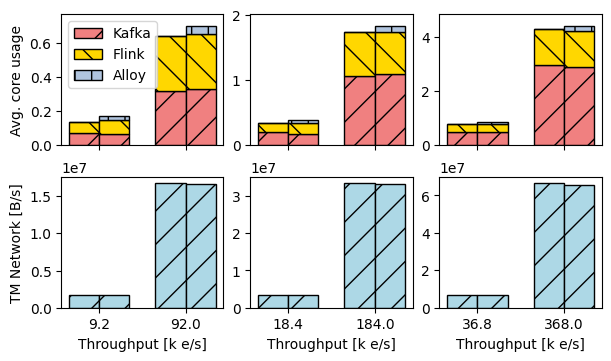

2


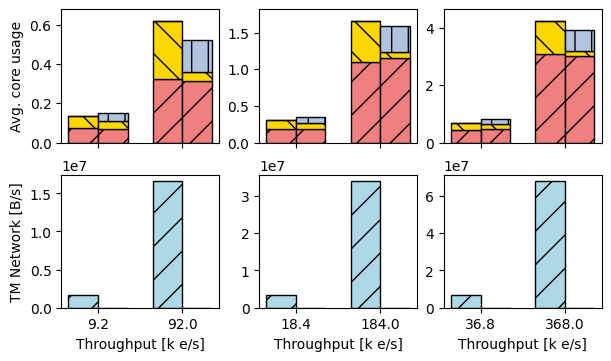

3


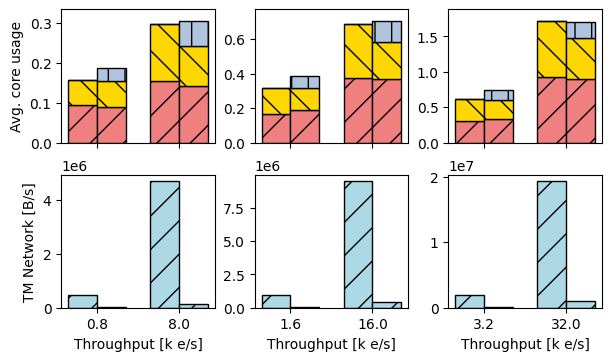

5


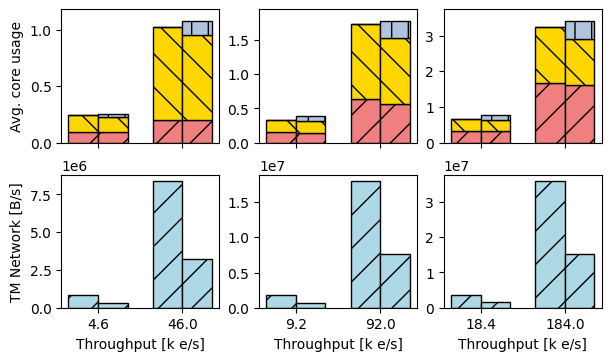

8


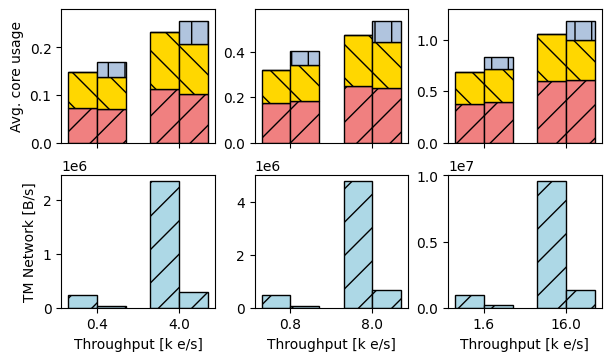

In [153]:
for q in queries:
    print(q)
    df = experiments[experiments["query"] == q]
    data = parse_data_per_query(df)
    plot_per_query(data, q)
    